In [1]:
#Code for central or centralv2
#Can be used just by switching the csv file path
#the cell below is used for centralv2 as an example

In [41]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np


# Central Codes (Can be used for Central or Centralv2)
scenario = "Central Restrict v2"

# Path to shapefile
shapefile_path = 'drive-download-2025countyoutlines-1-001.zip' 
shapefile_path = '/Users/grace/Library/CloudStorage/GoogleDrive-gracecwu@ucsb.edu/My Drive/Research_Projects/WRI_biomass/Downscaling_biomass/outputs/county_outlines.shp'

# Path to biomass results
csv_path = 'county_results_central.restrict.v2 - county_results_central.restrict.v2.csv' 
csv_path = '/Users/grace/Library/CloudStorage/GoogleDrive-gracecwu@ucsb.edu/My Drive/Research_Projects/WRI_biomass/Downscaling_biomass/outputs/county_results_central.restrict.v2.csv'

# Year Filter (choose whichever year)
selected_year = 2050

# Output file
output_path = '/Users/grace/Library/CloudStorage/GoogleDrive-gracecwu@ucsb.edu/My Drive/Research_Projects/WRI_biomass/Downscaling_biomass/spatialOutputs/'

output_geojson = os.path.join(output_path, f"biomass_by_county_{selected_year}_{scenario}.geojson")
output_shpfile = os.path.join(output_path, f"biomass_by_county_{selected_year}_{scenario}.shp")

In [2]:
# For Loading County Shapefile

gdf = gpd.read_file(shapefile_path)
# just drop the missing FIPS in case
gdf = gdf[gdf['fips'].notnull()]


In [3]:
gdf.head()

,fips,geometry
0,31039.0,"POLYGON ((-97.01952 42.0041, -97.01952 42.0049..."
1,53069.0,"POLYGON ((-123.43639 46.2382, -123.44759 46.24..."
2,35011.0,"POLYGON ((-104.56739 33.99757, -104.56772 33.9..."
3,31109.0,"POLYGON ((-96.9106 40.95841, -96.9106 40.95854..."
4,31129.0,"POLYGON ((-98.27367 40.0894, -98.27367 40.0894..."


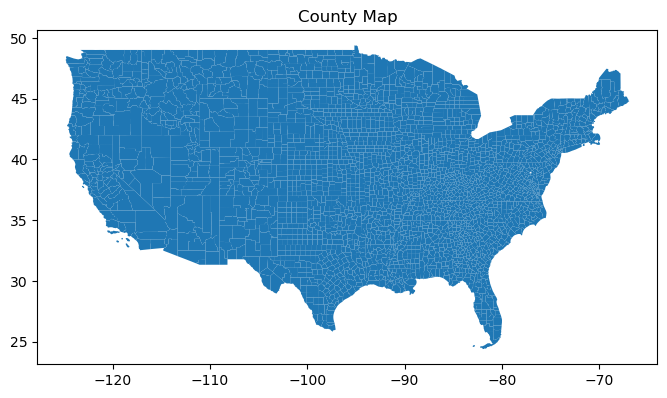

In [4]:
#gdf.plot(figsize=(8, 6))
#plt.title("County Map")
#plt.show()

In [5]:
# Convert from float to int to str.zfill(5) (because it wonn't compute the data) 
gdf['fips'] = gdf['fips'].astype(float).astype(int).astype(str).str.zfill(5)


print(f"✅ Loaded shapefile with {len(gdf)} counties.")


✅ Loaded shapefile with 3107 counties.


In [42]:
#Load Biomass Data

df = pd.read_csv(csv_path)

# Ensure FIPS is string with 5 digits
df['fips'] = df['fips'].astype(str).str.zfill(5)


In [43]:
df.head()

,zone,state,fips,county,sqmi,year,category,name,tons_of_production,land_use_factor,production_acres
0,alaska_emm,alaska,02020,anchorage,1716,2035,Municipal waste and residues,landfill gas,3115.874977,NaN,NaN
1,alaska_emm,alaska,02020,anchorage,1716,2050,Municipal waste and residues,landfill gas,6688.408146,NaN,NaN
2,alaska_emm,alaska,02122,kenai peninsula,10447,2035,Woody,pnw foretry 1,187413.580497,19.072864,9826.18986
3,alaska_emm,alaska,02122,kenai peninsula,10447,2050,Woody,pnw foretry 2,133681.924055,NaN,NaN
4,alaska_emm,alaska,02122,kenai peninsula,10447,2035,Woody,pnw foretry 4,567.960687,NaN,NaN


In [44]:
# Filter by selected year
df = df[df['year'] == selected_year]

if df.empty:
    raise ValueError(f"No data found for year {selected_year}")

print(f"✅ Loaded {len(df)} biomass records for year {selected_year}.")

✅ Loaded 37627 biomass records for year 2050.


In [45]:
df.head()

,zone,state,fips,county,sqmi,year,category,name,tons_of_production,land_use_factor,production_acres
1,alaska_emm,alaska,02020,anchorage,1716,2050,Municipal waste and residues,landfill gas,6688.408146,NaN,NaN
3,alaska_emm,alaska,02122,kenai peninsula,10447,2050,Woody,pnw foretry 2,133681.924055,NaN,NaN
5,alaska_emm,alaska,02122,kenai peninsula,10447,2050,Woody,pnw foretry 4,812.896958,NaN,NaN
7,alaska_emm,alaska,02122,kenai peninsula,10447,2050,Woody,pnw foretry 6,413.245582,NaN,NaN
9,carolinas_emm,north carolina,37001,alamance,434,2050,Municipal waste and residues,construction & demolition waste,11217.110840,NaN,NaN


In [46]:
# Aggregate Biomass Data (maybe fix because it could be cause of why all the data looks the same?)

biomass_summary_byCategory = df.groupby(['fips', 'category']).agg({
    'tons_of_production': 'sum',
    'production_acres': 'sum',
    'land_use_factor': 'mean' 
}).reset_index()

biomass_summary = df.groupby(['fips']).agg({
    'tons_of_production': 'sum',
    'production_acres': 'sum',
    'land_use_factor': 'mean' 
}).reset_index()

# print(f"✅ Aggregated biomass data for {len(biomass_summary)} counties.")

# Add log-transformed columns
biomass_summary_byCategory['log_tons'] = np.log(biomass_summary_byCategory['tons_of_production'])
biomass_summary_byCategory['log_acres'] = np.log(biomass_summary_byCategory['production_acres'])

# Add log-transformed columns
biomass_summary['log_tons'] = np.log(biomass_summary['tons_of_production'])
biomass_summary['log_acres'] = np.log(biomass_summary['production_acres'])


/opt/anaconda3/envs/geoviz/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geoviz/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geoviz/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [47]:
biomass_summary.head()

,fips,tons_of_production,production_acres,land_use_factor,log_tons,log_acres
0,01001,39399.295882,72.057894,2.623945,10.581503,4.277470
1,01003,87670.560513,544.867618,2.623945,11.381341,6.300543
2,01005,51732.840653,135.532481,2.623945,10.853848,4.909211
3,01007,55388.396677,347.997906,2.623945,10.922125,5.852196
4,01009,39228.911464,156.415558,2.623945,10.577169,5.052516


In [48]:
# Merge With County Shapes

gdf_merged = gdf.merge(biomass_summary, on='fips', how='left')

# how many counties received data
num_with_data = gdf_merged['tons_of_production'].notnull().sum()
print(f"✅ Joined data: {num_with_data} counties have biomass values.")


✅ Joined data: 3101 counties have biomass values.


In [49]:
gdf_merged.head()

,fips,geometry,tons_of_production,production_acres,land_use_factor,log_tons,log_acres
0,31039,"POLYGON ((-97.01952 42.0041, -97.01952 42.0049...",596263.953060,651.186090,2.623945,13.298439,6.478795
1,53069,"POLYGON ((-123.43639 46.2382, -123.44759 46.24...",27551.892363,244.624250,1.092653,10.223827,5.499723
2,35011,"POLYGON ((-104.56739 33.99757, -104.56772 33.9...",4428.231250,2710.316633,2.623945,8.395756,7.904821
3,31109,"POLYGON ((-96.9106 40.95841, -96.9106 40.95854...",430044.492738,8483.257119,2.623945,12.971644,9.045850
4,31129,"POLYGON ((-98.27367 40.0894, -98.27367 40.0894...",72350.099273,394.875845,2.623945,11.189272,5.978571


In [50]:
col = "production_acres"

# make sure the column is numeric and finite
gdf_merged[col] = pd.to_numeric(gdf_merged[col], errors="coerce")
gdf_merged[col].replace([np.inf, -np.inf], np.nan, inplace=True)

print(gdf_merged[col].describe())           # check min/max
print("NaN count:", gdf_merged[col].isna().sum())

# compute min/max from finite values only
vmin = gdf_merged[col].min(skipna=True)
vmax = gdf_merged[col].max(skipna=True)

count      3101.000000
mean       5070.440058
std       16213.175032
min           0.000000
25%          18.095927
50%         336.783430
75%        2326.759165
max      291581.319829
Name: production_acres, dtype: float64
NaN count: 6


/var/folders/43/1kn588md0ws63__7pjcxcjm80000gn/T/ipykernel_83083/118971087.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf_merged[col].replace([np.inf, -np.inf], np.nan, inplace=True)


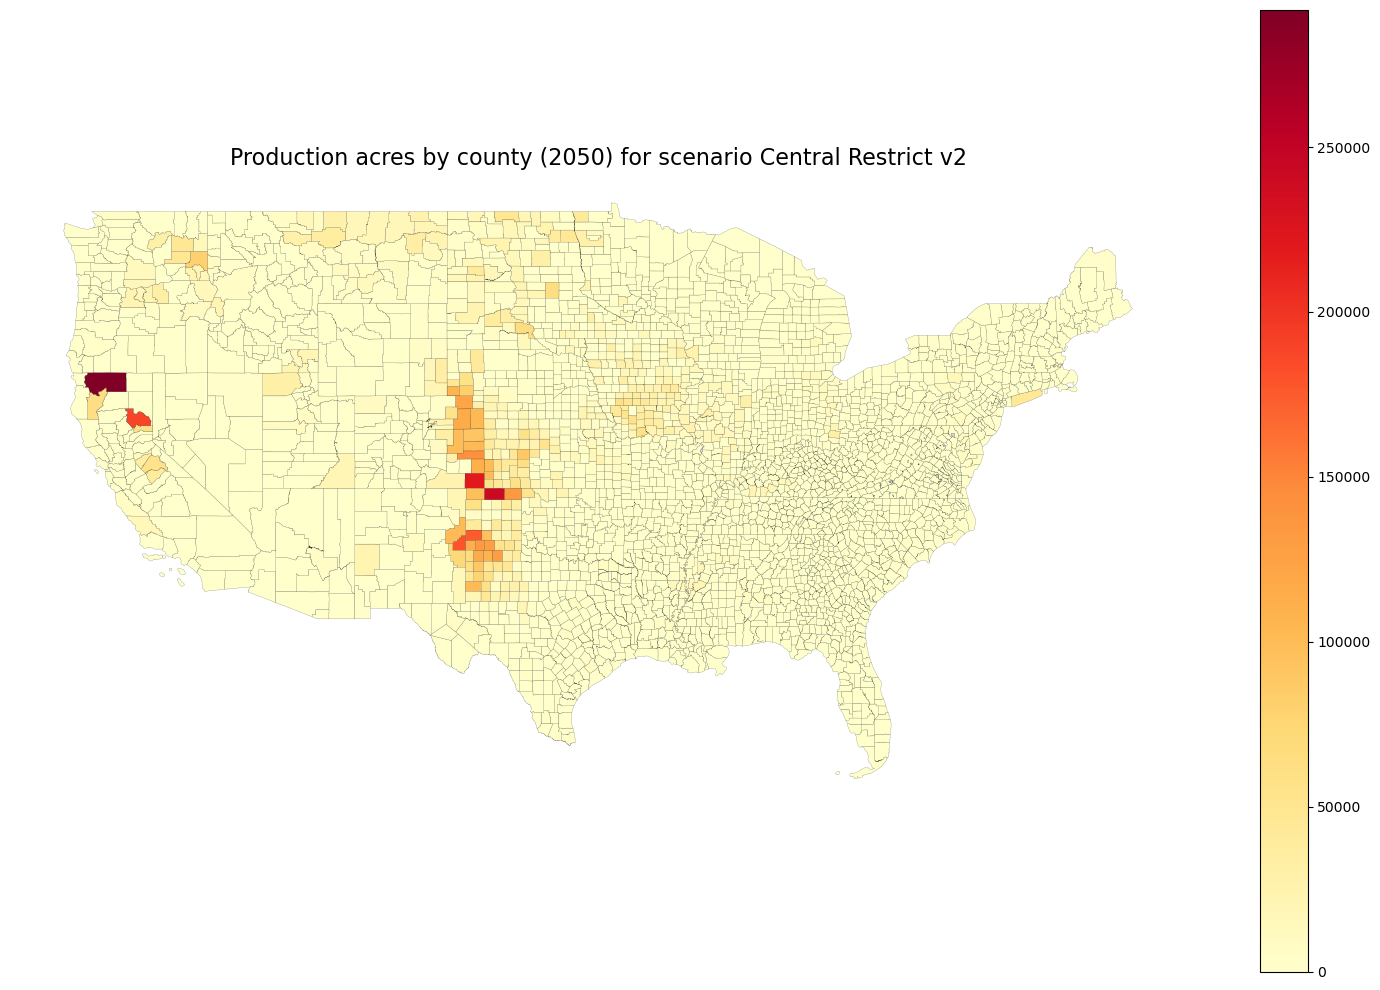

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf_merged.plot(
    column=col,
    cmap="YlOrRd",
    linewidth=0.1,
    edgecolor="black",
    ax=ax,
    legend=True,
    vmin=vmin, vmax=vmax,                       # <- key
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title(f"Production acres by county ({selected_year}) for scenario {scenario}", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Export to GeoJSON 
gdf_merged.to_file(output_geojson, driver='GeoJSON')

# Export to shpfile 
gdf_merged.to_file(output_shpfile, driver='ESRI Shapefile')
